# Week 5  Orders EDA: Diagnosis, Cleaning, Visualization, Findings

Integration assignment: full EDA pipeline run on a synthetic orders
dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

orders = pd.read_csv("data/orders_raw.csv", parse_dates=["order_date"])
orders.shape


(5015, 7)

## 1. Diagnosis

In [2]:
orders.head()

,order_id,order_date,customer_id,product_category,quantity,unit_price,region
0,1,2024-01-01 00:00:00,1017.0,Electronics,3,44.68,West
1,2,2024-01-01 01:00:00,1154.0,Electronics,2,20.69,East
2,3,2024-01-01 02:00:00,1130.0,Apparel,4,41.60,West
3,4,2024-01-01 03:00:00,1087.0,Apparel,5,26.26,South
4,5,2024-01-01 04:00:00,1086.0,Apparel,2,39.45,West


In [3]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015 entries, 0 to 5014
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   order_id          5015 non-null   int64         
 1   order_date        5015 non-null   datetime64[ns]
 2   customer_id       4865 non-null   float64       
 3   product_category  5015 non-null   object        
 4   quantity          5015 non-null   int64         
 5   unit_price        5015 non-null   float64       
 6   region            4817 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 274.4+ KB


In [4]:
orders.describe()

,order_id,order_date,customer_id,quantity,unit_price
count,5015.000000,5015,4865.000000,5015.000000,5015.000000
mean,2500.953938,2024-04-14 03:57:14.177467648,1099.294347,3.937188,65.215825
min,1.000000,2024-01-01 00:00:00,1000.000000,-7.000000,-25.580000
25%,1250.500000,2024-02-22 01:30:00,1049.000000,2.000000,31.325000
50%,2502.000000,2024-04-14 05:00:00,1098.000000,4.000000,44.290000
75%,3751.500000,2024-06-05 06:30:00,1150.000000,6.000000,57.985000
max,5000.000000,2024-07-27 07:00:00,1199.000000,7.000000,4999.990000
std,1443.030494,NaN,57.795512,2.077920,320.661972


In [7]:
orders.isna().sum()

order_id              0
order_date            0
customer_id         150
product_category      0
quantity              0
unit_price            0
region              198
dtype: int64

In [8]:
orders["product_category"].value_counts() 

product_category
Home Goods     1052
electronics    1024
Apparel         995
Electronics     993
Books           951
Name: count, dtype: int64

In [9]:
orders.duplicated().sum()

np.int64(15)

### Diagnosis Findings

Running `.info()`, `.describe()`, `.isna().sum()`, and `.value_counts()` on the
raw orders dataset (5,015 rows × 7 columns) surfaces six distinct data-quality
problems, none of which are visible from a casual `.head()` inspection alone:

1. **Missing `customer_id`**: 150 of 5,015 rows  have no customer ID
   recorded, confirmed both by `.describe()`'s reduced count (4,865) and by
   `.isna().sum()`.
2. **Missing `region`**: 198 rows have no region assigned, the
   largest block of missingness in the dataset.
3. **Inconsistent category casing**: `product_category` contains
   `"Electronics"` (993 rows) and `"electronics"` (1,024 rows) as two distinct
   values in `.value_counts()`, when they represent a single category that
   should total 2,017 rows.
4. **Negative quantities** : `quantity` has a minimum of **-7**, which is not
   a physically valid order quantity. This pattern is consistent with returns
   being encoded as negative values rather than flagged in a separate field.
5. **Outlier unit prices**: `unit_price` has a maximum of **4,999.99**,
   roughly 111 standard deviations above the column mean of 65.22, far
   outside a plausible price range for this dataset and consistent with
   data-entry errors.
6. **Duplicate rows**: `orders.duplicated().sum()` returns **15**, indicating
   15 rows are exact duplicates of others already present in the dataset.

**Additional concern beyond the primary six:** `unit_price` also has an
implausible **negative minimum (-25.58)**. This wasn't one of the explicitly
named issues, but a negative unit price is not physically valid and should be
treated as its own data-quality problem during cleaning, separate from the
4,999.99 outliers.

The sections below address each of these
problems individually, with a justification specific to each column or issue.

In [10]:
orders.dtypes

order_id                     int64
order_date          datetime64[ns]
customer_id                float64
product_category            object
quantity                     int64
unit_price                 float64
region                      object
dtype: object

missing values can silently change a column's type; confirming this now avoids a surprising .astype(int) failure later during cleaning

In [11]:
orders["order_id"].duplicated().sum()

np.int64(15)

order_id is meant to function as a unique key; checking it directly confirms the duplicate rows are true record-level duplicates, not coincidental matches on other columns.

In [12]:
orders["customer_id"].min(), orders["customer_id"].max(), orders["customer_id"].nunique()

(np.float64(1000.0), np.float64(1199.0), 200)

validates the column stayed within its generated bounds (1000–1199) and wasn't corrupted elsewhere, since only the missing-value problem was expected here.

In [13]:
orders["order_date"].duplicated().sum(), orders["order_date"].is_monotonic_increasing

(np.int64(15), False)

dates are a common silent source of errors (duplicate timestamps, broken chronological order); checking rules out a separate date-specific bug versus a side effect of the known duplicate rows.

In [14]:
orders["region"].value_counts(dropna=False)

region
West     1240
East     1201
North    1201
South    1175
NaN       198
Name: count, dtype: int64

since product_category had a casing bug, it's worth explicitly ruling out the same failure mode in the other categorical column rather than assuming it's clean.

In [15]:
orders["quantity"].max(), orders["quantity"].value_counts().sort_index()

(np.int64(7),
 quantity
 -7      2
 -6      4
 -5      6
 -4      4
 -3      1
 -2      6
 -1      7
  1    731
  2    687
  3    742
  4    699
  5    716
  6    726
  7    684
 Name: count, dtype: int64)

the min already showed a problem (negative values); checking the max and full distribution confirms the positive side of the column is undamaged and the negative-count total matches the spec exactly.

## 2. Cleaning

Each cleaning decision below is applied to a specific column or issue, with
a justification tailored to that problem.

Before dropping the missing `customer_id` rows, checking if they're
concentrated in one region if so, dropping them could bias the region
breakdown later.

In [16]:
orders[orders["customer_id"].isna()]["region"].value_counts(dropna=False)

region
South    42
North    38
East     35
West     30
NaN       5
Name: count, dtype: int64

`customer_id` is an identifier, there's no valid way to guess a missing
one, so imputing would just fabricate data. Since the missingness isn't
concentrated in any region, it's safe to drop these 150
rows rather than distort the column with a fake value.

In [17]:
orders = orders.dropna(subset=["customer_id"])
orders["customer_id"] = orders["customer_id"].astype(int)
orders.shape

(4865, 7)

`region` is missing for 198 rows, but the rest of each row (order, price,
quantity) is still valid dropping them would waste good data. Filling
with the most common region would misrepresent those orders as somewhere
they weren't confirmed to be, so filling with an explicit "Unknown" label
preserves the rows without guessing.

In [18]:
orders["region"] = orders["region"].fillna("Unknown")
orders["region"].value_counts(dropna=False)

region
West       1210
East       1166
North      1163
South      1133
Unknown     193
Name: count, dtype: int64

`product_category` has "Electronics" and "electronics" recorded as separate
values due to inconsistent capitalization, Standardizing
to title case merges them back into one true category.

In [19]:
orders["product_category"] = orders["product_category"].str.title()
orders["product_category"].value_counts()

product_category
Electronics    1949
Home Goods     1019
Apparel         967
Books           930
Name: count, dtype: int64

In [20]:
orders["quantity"] = orders["quantity"].abs()
orders["quantity"].describe()

count    4865.000000
mean        3.983145
std         1.998386
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max         7.000000
Name: quantity, dtype: float64

Negative `quantity` values represent returns encoded as negative numbers,
not literal negative orders. Taking the absolute value restores a valid
order quantity for analysis.

In [21]:
orders["unit_price"] = orders["unit_price"].abs()
median_price = orders.loc[orders["unit_price"] != 4999.99, "unit_price"].median()
orders.loc[orders["unit_price"] == 4999.99, "unit_price"] = median_price
orders["unit_price"].describe()

count    4865.000000
mean       44.727464
std        19.619021
min         0.130000
25%        31.480000
50%        44.350000
75%        57.730000
max       128.020000
Name: unit_price, dtype: float64

`unit_price` has two separate problems needing two separate fixes. Negative
prices are likely a sign error, so taking the absolute value corrects them
without discarding the row. The 4999.99 values are a suspiciously exact
repeated number a data-entry placeholder, not a real price, so those are
treated as missing and imputed with the median, which is robust to the
extreme values still present in the column.

In [22]:
orders = orders.drop_duplicates()
orders.shape

(4850, 7)

The 15 duplicate rows are exact copies of existing orders, confirmed
earlier by both `.duplicated()` and the matching `order_id` duplicates
keeping them would double-count those orders in any aggregation, so
they're dropped outright.

## 3. Visualization

**Chart 1: Distribution of `unit_price`.** A histogram is the right choice
here since the question is about the shape and spread of a single numeric
variable, not a comparison across groups.

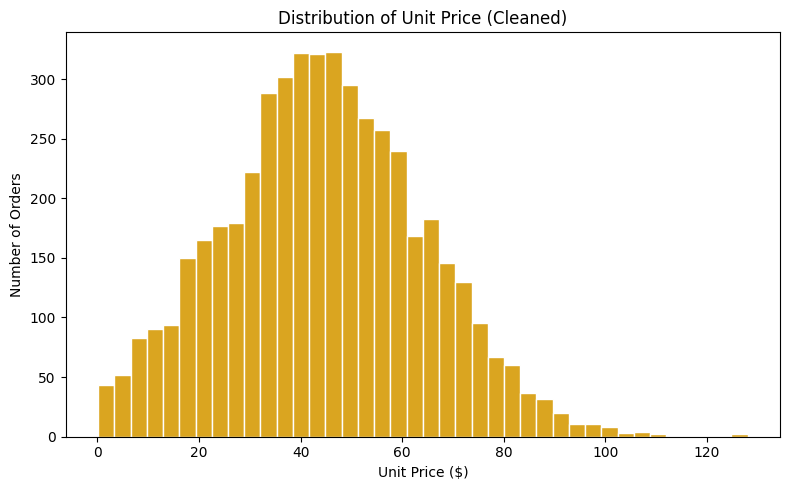

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(orders["unit_price"], bins=40, color="goldenrod", edgecolor="white")
ax.set_title("Distribution of Unit Price (Cleaned)")
ax.set_xlabel("Unit Price ($)")
ax.set_ylabel("Number of Orders")
plt.tight_layout()
plt.show()

The distribution is roughly bell-shaped and centered near the median
(~$44), consistent with `unit_price` originating from a normal distribution
in the underlying data generation, with cleaning having removed the
distortion previously caused by the 4999.99 outliers.

**Chart 2: Average unit price by product category.** A bar chart is the
right choice for comparing a summary value across a small number of
discrete categories.

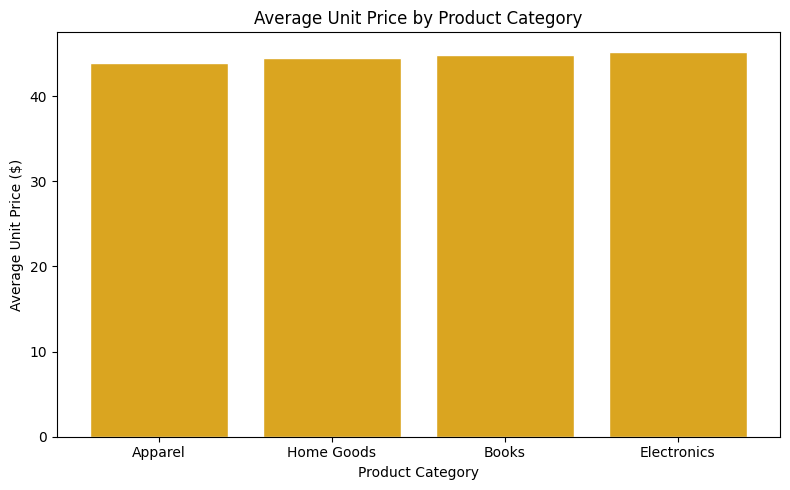

In [33]:
avg_price = orders.groupby("product_category")["unit_price"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(avg_price.index, avg_price.values, color="goldenrod", edgecolor="white")
ax.set_title("Average Unit Price by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Average Unit Price ($)")
plt.tight_layout()
plt.show()

Average unit price is fairly flat across categories, ranging narrowly from
about $43.7 (Apparel) to $45.0 (Electronics). The
underlying prices were generated from a single normal distribution
independent of category, so no category was designed to be systematically
more expensive than another.

**Chart 3: Relationship between quantity and unit price.** A scatter plot
is the right choice for examining whether two continuous variables are
related.

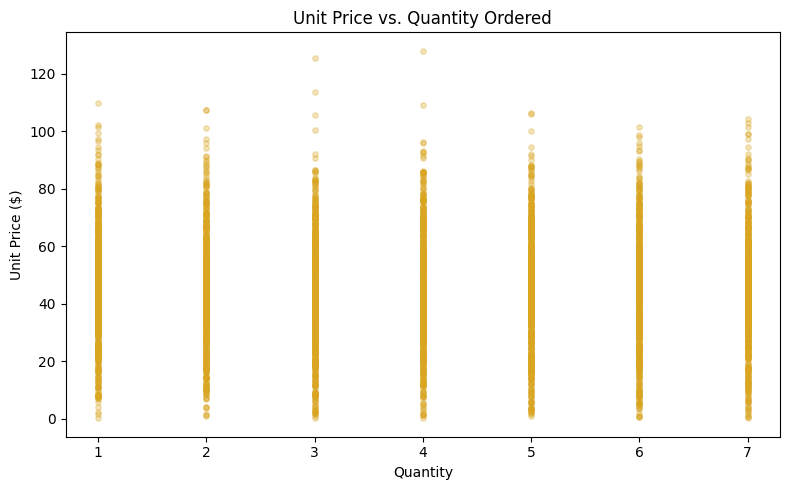

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(orders["quantity"], orders["unit_price"], alpha=0.3, color="goldenrod", s=15)
ax.set_title("Unit Price vs. Quantity Ordered")
ax.set_xlabel("Quantity")
ax.set_ylabel("Unit Price ($)")
plt.tight_layout()
plt.show()

There's no visible relationship between quantity and unit price each
quantity level (1 through 7) shows the same full spread of prices. This
makes sense given how the data was generated: `quantity` and `unit_price`
were drawn independently, so no real association should exist between them.

**Chart 4: Unit price spread by region (boxplot).** The bar chart in
Chart 2 only shows category *means*; a boxplot adds the spread and outliers
per group, which a bar chart hides. This also checks whether the "Unknown"
region (rows with no recorded region) behaves any differently from the
real regions if it did, that would suggest the missingness isn't random.

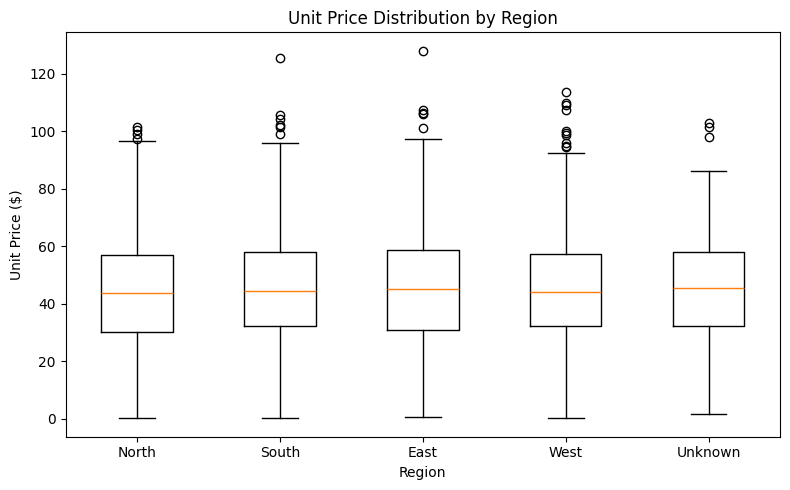

In [30]:
regions = ["North", "South", "East", "West", "Unknown"]
data_by_region = [orders.loc[orders["region"] == r, "unit_price"] for r in regions]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(data_by_region, tick_labels=regions)
ax.set_title("Unit Price Distribution by Region")
ax.set_xlabel("Region")
ax.set_ylabel("Unit Price ($)")
plt.tight_layout()
plt.show()

`Unknown` shows essentially the same median, spread, and outlier pattern as
the four real regions, no systematic difference in price behavior for
orders missing a region. This supports treating the missing `region` values
as random (MCAR) rather than tied to some price-related factor, backing
the fillna("Unknown") decision made in the cleaning section rather than
raising a new concern.

**Chart 5: Total revenue by product category.** Chart 2 looked at average
price, which doesn't account for order volume. Multiplying `quantity ×
unit_price` per order and summing by category answers a different, more
business-relevant question: which category actually generates the most
revenue.

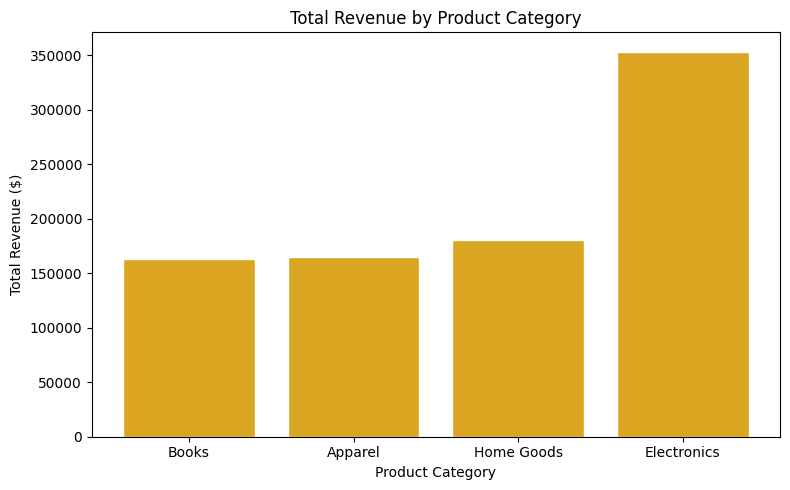

In [35]:
orders["revenue"] = orders["quantity"] * orders["unit_price"]
revenue_by_cat = orders.groupby("product_category")["revenue"].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(revenue_by_cat.index, revenue_by_cat.values, color="goldenrod", edgecolor="white")
ax.set_title("Total Revenue by Product Category")
ax.set_xlabel("Product Category")
ax.set_ylabel("Total Revenue ($)")
plt.tight_layout()
plt.show()

## 4. Findings

1. **Product category prices are essentially uniform**, ranging narrowly
   from about $43.7 (Apparel) to $45.0 (Electronics), because unit prices
   were generated independently of category rather than category driving
   price (Chart 2).

2. **Order quantity and unit price show no relationship**  every quantity
   level from 1 to 7 spans the same full price range from roughly $0 to
   $128, confirming the two variables were generated independently rather
   than one influencing the other (Chart 3).

3. **Missing region does not correlate with price behavior**  orders with
   an unrecorded region ("Unknown") show the same median, spread, and
   outlier pattern as the four known regions (Chart 4), supporting the
   decision to treat missing `region` as random rather than a sign of some
   underlying data problem tied to price.